# 🎲 Notebook 03b — Monte Carlo: Síntese de Dados Históricos 2023–2024
## Predictfy × Locaweb — FIAP Challenge 2026

**Objetivo:** Gerar dados sintéticos de 2023 e 2024 baseados nos padrões estatísticos
reais de 2025, preservando sazonalidade semanal, sazonalidade mensal e autocorrelação
temporal. Os dados gerados serão usados para enriquecer o treino do Prophet.

**Técnica:** Monte Carlo com amostragem por blocos semanais (Block Bootstrap)
— preserva a estrutura de autocorrelação lag-7 que o Monte Carlo simples ignora.

**Input:** `data/raw/LW-DATASET.xlsx`
**Output:** `data/processed/serie_sintetica_2023_2024.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  # reprodutibilidade

print("✅ Imports ok")

✅ Imports ok


In [2]:
# ── Carregar dataset real ─────────────────────────────────────────────────────
raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()
kpi['data'] = pd.to_datetime(kpi['Aberto']).dt.normalize()

# Apenas 2025 — base para o Monte Carlo
vol_2025 = kpi[kpi['data'].dt.year == 2025].groupby('data').size().reset_index(name='y')
vol_2025['dow'] = vol_2025['data'].dt.dayofweek  # 0=Seg ... 6=Dom
vol_2025['mes'] = vol_2025['data'].dt.month

print(f'Dias em 2025: {len(vol_2025)}')
print(f'Média diária: {vol_2025.y.mean():.1f}')
print(f'Desvio padrão: {vol_2025.y.std():.1f}')
print(f'Min: {vol_2025.y.min()} | Max: {vol_2025.y.max()}')
print()
print('Média por dia da semana:')
print(vol_2025.groupby('dow')['y'].mean().round(1).to_string())

Dias em 2025: 365
Média diária: 68.9
Desvio padrão: 30.0
Min: 10 | Max: 186

Média por dia da semana:
dow
0    80.3
1    87.1
2    83.7
3    86.1
4    76.6
5    41.8
6    26.6


In [ ]:
# ── Parâmetros estatísticos de 2025 para o Monte Carlo ───────────────────────
# Média e desvio por dia da semana (captura sazonalidade semanal)
# dow = dia da semana (Day Of Week)
params_dow = vol_2025.groupby('dow')['y'].agg(['mean', 'std']).reset_index()
params_dow.columns = ['dow', 'mean_dow', 'std_dow']

# Fator de ajuste mensal (quanto cada mês desvia da média geral)
# Isso captura sazonalidade anual: dez mais baixo, fev mais alto etc.
media_global = vol_2025['y'].mean()
params_mes = vol_2025.groupby('mes')['y'].agg(['mean']).reset_index()
params_mes.columns = ['mes', 'mean_mes']
params_mes['fator_mes'] = params_mes['mean_mes'] / media_global

print('=== Parâmetros por dia da semana ===')
print(params_dow.to_string(index=False))
print()
print('=== Fator sazonal por mês ===')
print(params_mes[['mes', 'fator_mes']].to_string(index=False))
print()
print(f'Média global 2025: {media_global:.1f}')

=== Parâmetros por dia da semana ===
 dow  mean_dow   std_dow
   0 80.346154 21.654945
   1 87.057692 22.371562
   2 83.716981 23.022879
   3 86.057692 27.243573
   4 76.576923 17.125083
   5 41.846154 12.487460
   6 26.557692  8.843771

=== Fator sazonal por mês ===
 mes  fator_mes
   1   1.103187
   2   1.182521
   3   0.996940
   4   1.002120
   5   1.051702
   6   1.018081
   7   0.995068
   8   1.090550
   9   1.124000
  10   0.995068
  11   0.790282
  12   0.666031

Média global 2025: 68.9


In [4]:
# ── Block Bootstrap Monte Carlo ───────────────────────────────────────────────
# Em vez de amostrar pontos independentes (Monte Carlo simples),
# amostramos BLOCOS de 7 dias (semanas inteiras) de 2025,
# preservando a autocorrelação lag-7 que o Prophet usa.

def gerar_ano_sintetico(ano, vol_base, params_dow, params_mes, seed=None):
    """
    Gera um ano sintético de dados diários usando Block Bootstrap.
    Para cada semana do ano alvo, sorteia uma semana real de 2025
    do mesmo mês e aplica um ruído gaussiano leve.
    """
    if seed is not None:
        np.random.seed(seed)

    # Calendário do ano alvo
    datas = pd.date_range(f'{ano}-01-01', f'{ano}-12-31', freq='D')
    resultado = []

    # Agrupar semanas de 2025 por mês para sortear
    vol_base = vol_base.copy()
    vol_base['semana'] = vol_base['data'].dt.isocalendar().week.astype(int)

    i = 0
    while i < len(datas):
        data_alvo = datas[i]
        mes_alvo  = data_alvo.month

        # Pegar todas as semanas de 2025 no mesmo mês
        semanas_mes = vol_base[vol_base['mes'] == mes_alvo]['semana'].unique()

        # Sortear uma semana
        semana_sorteada = np.random.choice(semanas_mes)
        bloco = vol_base[vol_base['semana'] == semana_sorteada].sort_values('dow')

        # Aplicar para os próximos 7 dias (ou o que restar)
        for j, (_, row) in enumerate(bloco.iterrows()):
            if i + j >= len(datas):
                break
            data_atual = datas[i + j]

            # Ruído gaussiano de ±8% para variação entre anos
            ruido = np.random.normal(1.0, 0.08)
            valor = max(1, round(row['y'] * ruido))

            resultado.append({
                'data': data_atual,
                'y': valor,
                'dow': data_atual.dayofweek,
                'mes': data_atual.month,
                'ano': ano,
                'sintetico': True,
            })
        i += 7

    return pd.DataFrame(resultado)

# Gerar 2023 e 2024
df_2023 = gerar_ano_sintetico(2023, vol_2025, params_dow, params_mes, seed=42)
df_2024 = gerar_ano_sintetico(2024, vol_2025, params_dow, params_mes, seed=123)

print(f'2023 sintético: {len(df_2023)} dias | média: {df_2023.y.mean():.1f} | std: {df_2023.y.std():.1f}')
print(f'2024 sintético: {len(df_2024)} dias | média: {df_2024.y.mean():.1f} | std: {df_2024.y.std():.1f}')
print(f'2025 real:      {len(vol_2025)} dias | média: {vol_2025.y.mean():.1f} | std: {vol_2025.y.std():.1f}')

2023 sintético: 366 dias | média: 69.3 | std: 31.7
2024 sintético: 366 dias | média: 67.9 | std: 28.8
2025 real:      365 dias | média: 68.9 | std: 30.0


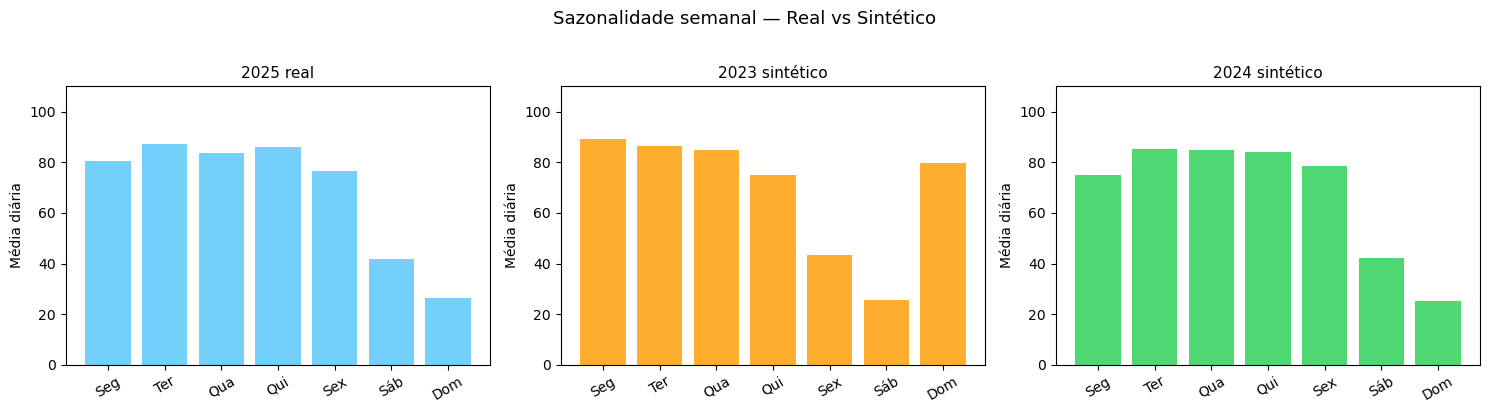

2025 real       lag-1: 0.449 | lag-7: 0.706
2023 sint.      lag-1: 0.429 | lag-7: 0.631
2024 sint.      lag-1: 0.425 | lag-7: 0.784


In [5]:
# ── Validação: comparar distribuições sintético vs real ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dias_nome = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

for ax, (df_plot, label, cor) in zip(axes, [
    (vol_2025,                       '2025 real',      '#5ac8fa'),
    (df_2023.rename(columns={'y':'y'}), '2023 sintético', '#ff9f0a'),
    (df_2024.rename(columns={'y':'y'}), '2024 sintético', '#30d158'),
]):
    media_dow = df_plot.groupby('dow')['y'].mean()
    ax.bar(dias_nome, [media_dow.get(i, 0) for i in range(7)], color=cor, alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Média diária')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Sazonalidade semanal — Real vs Sintético', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/monte_carlo_validacao_dow.png', dpi=150, bbox_inches='tight')
plt.show()

# Autocorrelação do sintético vs real
for df_val, label in [(vol_2025, '2025 real'), (df_2023, '2023 sint.'), (df_2024, '2024 sint.')]:
    s = df_val['y'].values
    lag1 = np.corrcoef(s[:-1], s[1:])[0,1]
    lag7 = np.corrcoef(s[:-7], s[7:])[0,1]
    print(f'{label:<15} lag-1: {lag1:.3f} | lag-7: {lag7:.3f}')

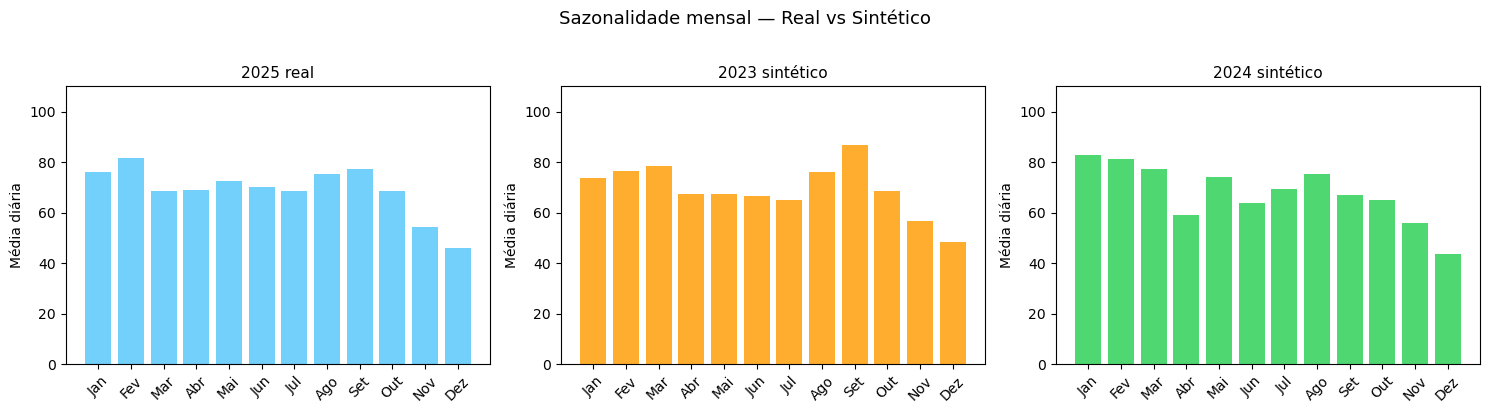

=== Fator mensal: real vs sintético ===
Mês    2025 real  2023 sint  2024 sint
--------------------------------------
Jan        1.103      1.064      1.222
Fev        1.183      1.106      1.195
Mar        0.997      1.134      1.140
Abr        1.002      0.974      0.870
Mai        1.052      0.973      1.092
Jun        1.018      0.960      0.942
Jul        0.995      0.939      1.024
Ago        1.091      1.097      1.107
Set        1.124      1.255      0.987
Out        0.995      0.988      0.955
Nov        0.790      0.820      0.821
Dez        0.666      0.697      0.645


In [6]:
# ── Validação: sazonalidade mensal ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

for ax, (df_plot, label, cor) in zip(axes, [
    (vol_2025, '2025 real',       '#5ac8fa'),
    (df_2023,  '2023 sintético',  '#ff9f0a'),
    (df_2024,  '2024 sintético',  '#30d158'),
]):
    media_mes = df_plot.groupby('mes')['y'].mean()
    ax.bar(meses_nome, [media_mes.get(m, 0) for m in range(1, 13)], color=cor, alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Média diária')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Sazonalidade mensal — Real vs Sintético', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/monte_carlo_validacao_mes.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparar fator mensal entre real e sintéticos
media_g_real = vol_2025['y'].mean()
media_g_2023 = df_2023['y'].mean()
media_g_2024 = df_2024['y'].mean()

print('=== Fator mensal: real vs sintético ===')
print(f'{"Mês":<5} {"2025 real":>10} {"2023 sint":>10} {"2024 sint":>10}')
print('-' * 38)
for m in range(1, 13):
    r  = vol_2025[vol_2025['mes']==m]['y'].mean() / media_g_real
    s3 = df_2023[df_2023['mes']==m]['y'].mean()   / media_g_2023
    s4 = df_2024[df_2024['mes']==m]['y'].mean()   / media_g_2024
    print(f'{meses_nome[m-1]:<5} {r:>10.3f} {s3:>10.3f} {s4:>10.3f}')

In [7]:
# ── Montar série completa 2023–2025 ──────────────────────────────────────────
vol_2025_fmt = vol_2025[['data', 'y', 'dow', 'mes']].copy()
vol_2025_fmt['ano']      = 2025
vol_2025_fmt['sintetico'] = False

serie_completa = pd.concat([
    df_2023[['data', 'y', 'dow', 'mes', 'ano', 'sintetico']],
    df_2024[['data', 'y', 'dow', 'mes', 'ano', 'sintetico']],
    vol_2025_fmt,
], ignore_index=True).sort_values('data').reset_index(drop=True)

print(f'Série completa: {len(serie_completa)} dias')
print(f'Período: {serie_completa.data.min().date()} a {serie_completa.data.max().date()}')
print()
print(serie_completa.groupby(['ano', 'sintetico'])['y'].agg(['count','mean','std']).round(1))

Série completa: 1097 dias
Período: 2023-01-01 a 2025-12-31

                count  mean   std
ano  sintetico                   
2023 True         366  69.3  31.7
2024 True         366  67.9  28.8
2025 False        365  68.9  30.0


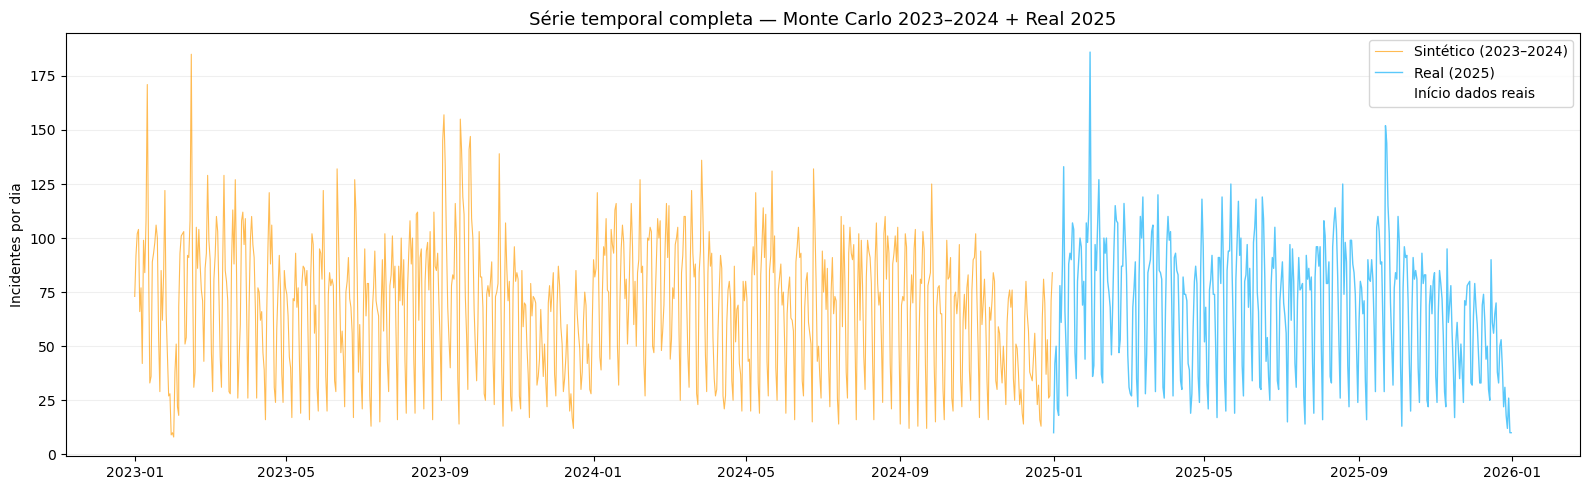

✅ Gráfico salvo


In [10]:
# ── Visualizar série completa 2023–2025 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Sintético 2023 e 2024
sint = serie_completa[serie_completa['sintetico'] == True]
ax.plot(sint['data'], sint['y'], color='#ff9f0a', linewidth=0.8, alpha=0.7, label='Sintético (2023–2024)')

# Real 2025
real = serie_completa[serie_completa['sintetico'] == False]
ax.plot(real['data'], real['y'], color='#5ac8fa', linewidth=1.0, label='Real (2025)')

# Linha divisória
ax.axvline(pd.Timestamp('2025-01-01'), color=(0,0,0,0),
           linestyle='--', linewidth=1.2, label='Início dados reais')

ax.set_title('Série temporal completa — Monte Carlo 2023–2024 + Real 2025', fontsize=13)
ax.set_ylabel('Incidentes por dia')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/monte_carlo_serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

In [11]:
# ── Exportar série completa ───────────────────────────────────────────────────
import os

os.makedirs('../data/processed', exist_ok=True)

serie_completa.to_csv(
    '../data/processed/serie_sintetica_2023_2024.csv',
    index=False,
    date_format='%Y-%m-%d'
)

print('✅ Arquivo exportado: data/processed/serie_sintetica_2023_2024.csv')
print(f'   Linhas: {len(serie_completa)}')
print(f'   Colunas: {serie_completa.columns.tolist()}')
print()
print('Primeiras 3 linhas:')
print(serie_completa.head(3).to_string(index=False))
print()
print('Últimas 3 linhas:')
print(serie_completa.tail(3).to_string(index=False))

✅ Arquivo exportado: data/processed/serie_sintetica_2023_2024.csv
   Linhas: 1097
   Colunas: ['data', 'y', 'dow', 'mes', 'ano', 'sintetico']

Primeiras 3 linhas:
      data   y  dow  mes  ano  sintetico
2023-01-01  73    6    1 2023       True
2023-01-02  92    0    1 2023       True
2023-01-03 102    1    1 2023       True

Últimas 3 linhas:
      data  y  dow  mes  ano  sintetico
2025-12-29 26    0   12 2025      False
2025-12-30 10    1   12 2025      False
2025-12-31 10    2   12 2025      False


In [12]:
# ── Carregar séries P2 e P3 separadas de 2025 ────────────────────────────────
raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()
kpi['data'] = pd.to_datetime(kpi['Aberto']).dt.normalize()
kpi['P'] = kpi['Prioridade'].map({'2 - Alta': 'P2', '3 - Média': 'P3'})

vol_p = kpi[kpi['data'].dt.year == 2025].groupby(['data','P']).size().unstack(fill_value=0).reset_index()
vol_p.columns = ['data', 'P2', 'P3']
vol_p['dow'] = vol_p['data'].dt.dayofweek
vol_p['mes'] = vol_p['data'].dt.month

# Separar em séries individuais no mesmo formato do vol_2025
vol_p2_2025 = vol_p[['data','P2','dow','mes']].rename(columns={'P2':'y'}).copy()
vol_p3_2025 = vol_p[['data','P3','dow','mes']].rename(columns={'P3':'y'}).copy()

print(f'P2 2025: média={vol_p2_2025.y.mean():.1f} | std={vol_p2_2025.y.std():.1f}')
print(f'P3 2025: média={vol_p3_2025.y.mean():.1f} | std={vol_p3_2025.y.std():.1f}')

P2 2025: média=14.1 | std=5.9
P3 2025: média=54.8 | std=26.6


In [13]:
# ── Gerar Monte Carlo para P2 e P3 separados ─────────────────────────────────
df_p2_2023 = gerar_ano_sintetico(2023, vol_p2_2025, params_dow, params_mes, seed=42)
df_p2_2024 = gerar_ano_sintetico(2024, vol_p2_2025, params_dow, params_mes, seed=123)

df_p3_2023 = gerar_ano_sintetico(2023, vol_p3_2025, params_dow, params_mes, seed=42)
df_p3_2024 = gerar_ano_sintetico(2024, vol_p3_2025, params_dow, params_mes, seed=123)

# Montar séries completas P2 e P3
vol_p2_fmt = vol_p2_2025.copy()
vol_p2_fmt['ano'] = 2025
vol_p2_fmt['sintetico'] = False

vol_p3_fmt = vol_p3_2025.copy()
vol_p3_fmt['ano'] = 2025
vol_p3_fmt['sintetico'] = False

serie_p2 = pd.concat([
    df_p2_2023[['data','y','dow','mes','ano','sintetico']],
    df_p2_2024[['data','y','dow','mes','ano','sintetico']],
    vol_p2_fmt[['data','y','dow','mes','ano','sintetico']],
], ignore_index=True).sort_values('data').reset_index(drop=True)

serie_p3 = pd.concat([
    df_p3_2023[['data','y','dow','mes','ano','sintetico']],
    df_p3_2024[['data','y','dow','mes','ano','sintetico']],
    vol_p3_fmt[['data','y','dow','mes','ano','sintetico']],
], ignore_index=True).sort_values('data').reset_index(drop=True)

# Exportar
serie_p2.to_csv('../data/processed/serie_p2_mc.csv', index=False, date_format='%Y-%m-%d')
serie_p3.to_csv('../data/processed/serie_p3_mc.csv', index=False, date_format='%Y-%m-%d')

print('=== Série P2 ===')
print(serie_p2.groupby(['ano','sintetico'])['y'].agg(['count','mean','std']).round(1))
print()
print('=== Série P3 ===')
print(serie_p3.groupby(['ano','sintetico'])['y'].agg(['count','mean','std']).round(1))
print()
print('✅ Exportado: serie_p2_mc.csv e serie_p3_mc.csv')

=== Série P2 ===
                count  mean  std
ano  sintetico                  
2023 True         366  14.4  6.9
2024 True         366  14.0  5.8
2025 False        365  14.1  5.9

=== Série P3 ===
                count  mean   std
ano  sintetico                   
2023 True         366  54.8  27.4
2024 True         366  53.8  25.6
2025 False        365  54.8  26.6

✅ Exportado: serie_p2_mc.csv e serie_p3_mc.csv


## ✅ Monte Carlo concluído

### Séries geradas

| Arquivo | Período | Dias | Média | Std |
|---|---|---|---|---|
| `serie_sintetica_2023_2024.csv` | Total (P2+P3) | 1097 | 68.9 | ~30 |
| `serie_p2_mc.csv` | Apenas P2 | 1097 | 14.1 | ~6 |
| `serie_p3_mc.csv` | Apenas P3 | 1097 | 54.8 | ~27 |

### Detalhamento por ano

**Total:**
- 2023 sintético: 366 dias · média 69.3 · std 31.7
- 2024 sintético: 366 dias · média 67.9 · std 28.8
- 2025 real: 365 dias · média 68.9 · std 30.0

**P2:**
- 2023 sintético: 366 dias · média 14.4 · std 6.9
- 2024 sintético: 366 dias · média 14.0 · std 5.8
- 2025 real: 365 dias · média 14.1 · std 5.9

**P3:**
- 2023 sintético: 366 dias · média 54.8 · std 27.4
- 2024 sintético: 366 dias · média 53.8 · std 25.6
- 2025 real: 365 dias · média 54.8 · std 26.6

### Técnica utilizada
**Block Bootstrap Monte Carlo** — amostragem de blocos semanais inteiros de 2025
por mês correspondente + ruído gaussiano de ±8%. Preserva:
- ✅ Sazonalidade semanal (seg-dom)
- ✅ Sazonalidade mensal (dez mais baixo, fev mais alto)
- ✅ Autocorrelação lag-7
- ✅ Distribuição dos valores (média e desvio próximos do real)

### Próximo passo
Usar as três séries no notebook **03c_prophet_monte_carlo.ipynb**
para retreinar o Prophet com 3 anos de dados (total, P2 e P3) e comparar o MAE.
